#### WRF Example Notebook - Single Variables

Demonstrates using ldcpy on wrf CONUS 404 data - single variables. 

On NCAR's Jupyterhub, environment NPL 2024b is a good option (Note: it contains an old version of ldcpy that does not support WRF data.  So make sure you have a recent version from https://github.com/NCAR/ldcpy.)

To look at SPERR-compressed data, you need the HDF5 plugin installed and the path specified in HDF5_PLUGIN_PATH. So let's verify that. (Note, I have all my plugins in the same zfp directory)

In [3]:
import os
# if this environment variable is not set, then you can set it as needed:
os.environ['HDF5_PLUGIN_PATH'] = '/glade/work/abaker/compress-libs/plugins_mar26/lib64'

In [4]:
import sys

import cf_xarray as cf
import numpy as np
import xarray as xr
import xwrf

%load_ext autoreload
%autoreload 2
%matplotlib inline

# loading our own ldcpy repo
sys.path.insert(0, '/glade/u/home/abaker/repos/my_ldcpy')
# suppress all of the divide by zero warnings
import warnings

# sys.path.insert(0, '/../../../')
import ldcpy

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import dask
from dask_jobqueue import PBSCluster

In [6]:
cluster = PBSCluster(
    # Basic job directives
    job_name='ldcpy-wrf-nb',
    queue='casper',
    walltime='60:00',
    # your project code
    account='NTDD0004',
    log_directory='dask-logs',
    # These settings impact the resources assigned to the job
    cores=1,
    memory='10GiB',
    resource_spec='select=1:ncpus=1:mem=10GB',
    # These settings define the resources assigned to a worker
    processes=1,
    # This controls where Dask will write data to disk if memory is exhausted
    local_directory='/local_scratch/pbs.$PBS_JOBID/dask/spill',
    # This specifies which network interface the cluster will use
    interface='ext',
    env_extra=[
    'export HDF5_PLUGIN_PATH=/glade/work/abaker/compress-libs/plugins_mar26/lib64'
]
)

In [7]:
from dask.distributed import Client

# Attach a "client" to our created cluster
client = Client(cluster)

# Display the client
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/abaker/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/abaker/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:38897,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/abaker/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [8]:
# Scale the cluster adaptively
cluster.adapt(minimum_jobs=1, maximum_jobs=36)
# Scale the cluster to some number of workers
# cluster.scale(2)
# Block progress until workers have spawned (optional - typically only in demos and benchmarks!)
# cluster.wait_for_workers(2)

In [10]:
#double check plugin path
client.run(lambda: __import__("os").environ.get("HDF5_PLUGIN_PATH"))

{'tcp://128.117.208.173:33911': '/glade/work/abaker/compress-libs/plugins_mar26/lib64'}

In [12]:
# Some CONUS 404 wrf data to look at (24 hourly sliced put into a single file for a single variable)
# (wrf2d_d01_2020-07-01_00:00:00 => wrf2d_d01_2020-07-01_23:00:00 , and then for 3d also)

# this contains lat/lon info
fileconsts = "/glade/campaign/cisl/asap/abaker/wrf_update/wrfconstants_usgs404.nc"

# get the file names
base_dir = "/glade/campaign/cisl/asap/abaker/wrf_update/wrf_24hr_combined_files/single_vars/"

# which variables do we have in this directory
varnames = os.listdir(base_dir)
print("Variables = ")
print(varnames)

# which compressor options
comp_opts = os.listdir(base_dir + varnames[0])
print("Compression options = ")
print(comp_opts)

Variables = 
['SST', 'RAINNCV', 'T2', 'P', 'V', 'Q2', 'U', 'ACECAN', 'SNLIQ', 'QFX', 'TK']
Compression options = 
['sperr_psnr120', 'sperr_psnr100', 'sperr_psnr160', 'sperr_psnr80', 'gbr_5', 'sperr_psnr60', 'sperr_psnr20', 'sperr_psnr220', 'gbr_3', 'sperr_psnr50', 'sperr_psnr180', 'sperr_psnr40', 'gbr_1', 'sperr_psnr140', 'sperr_psnr240', 'sperr_psnr200', 'gbr_4', 'pretreat', 'gbr_2', 'lossless']


In [14]:
# let's look at T2 data
varname = 'T2'
filename = 'wrf2d_combined_T2.nc'
ds_all = []
ds_label = []
ds_size = []
# wrf files have to be open and post-processsed
for i in comp_opts:
    full_filename = base_dir + varname + "/" + i + "/" + filename
    # print(full_filename)
    ds_label.append(i)
    ds_all.append(xr.open_dataset(full_filename, engine="netcdf4", chunks={"time": 1}).xwrf.postprocess())
    ds_size.append(os.path.getsize(full_filename))
t2_ds_dict = dict(zip(ds_label, ds_all))
t2_size_dict = dict(zip(ds_label, ds_size))

# sorted(t2_size_dict)
indx = np.argsort(ds_size)[::-1]
sorted_ds_size = [ds_size[i] for i in indx]
sorted_ds_label = [ds_label[i] for i in indx]
sorted_t2_size_dict = dict(zip(sorted_ds_label, sorted_ds_size))

# wrf coordinates file
ds_const = xr.open_dataset(fileconsts, engine="netcdf4").xwrf.postprocess()



In [15]:
# make an ldcpy collection of all of this T2 data
T2_col = ldcpy.collect_datasets(
    "wrf",
    ["T2"],
    ds_all,
    ds_label,
    coords_ds=ds_const,
    file_sizes=ds_size,
)

dataset size in GB 2.68



In [16]:
# Notation
# sperr_pweX = sperr with pointwise error tolerance X
# sperr_psnrX = sperr with peak-signal-to-noise ratio X
# zfp_pX = zfp with precision = X
# gbr_X = granular bit round with X significant digits

# compression ratio?
orig = sorted_t2_size_dict["lossless"]
for key in sorted_t2_size_dict:
    cr = round(orig / sorted_t2_size_dict[key], 2)
    print(key + ": ", cr)

sperr_psnr240:  0.54
pretreat:  0.54
sperr_psnr220:  0.6
sperr_psnr200:  0.68
sperr_psnr180:  0.78
sperr_psnr160:  0.92
lossless:  1.0
sperr_psnr140:  1.11
sperr_psnr120:  1.42
gbr_5:  1.64
gbr_4:  1.94
sperr_psnr100:  1.95
sperr_psnr80:  3.15
gbr_3:  3.94
sperr_psnr60:  6.62
sperr_psnr50:  11.9
gbr_2:  17.22
sperr_psnr40:  28.48
gbr_1:  32.46
sperr_psnr20:  415.71


In [17]:
# quick look at collection dataset
T2_col

<xarray.Dataset> Size: 3GB
Dimensions:     (collection: 20, Time: 24, y: 1015, x: 1367)
Coordinates:
    XTIME       (Time) datetime64[ns] 192B 2020-07-01 ... 2020-07-01T23:00:00
  * Time        (Time) datetime64[ns] 192B 2020-07-01 ... 2020-07-01T23:00:00
    XLAT        (y, x) float32 6MB 17.65 17.66 17.67 17.68 ... 51.73 51.71 51.69
    XLONG       (y, x) float32 6MB -122.6 -122.5 -122.5 ... -57.17 -57.12 -57.07
  * x           (x) float64 11kB -2.732e+06 -2.728e+06 ... 2.728e+06 2.732e+06
  * y           (y) float64 8kB -2.028e+06 -2.024e+06 ... 2.024e+06 2.028e+06
  * collection  (collection) <U13 1kB 'sperr_psnr120' ... 'lossless'
Data variables:
    T2          (collection, Time, y, x) float32 3GB dask.array<chunksize=(1, 1, 1015, 1367), meta=np.ndarray>
Attributes: (12/152)
    TITLE:                            OUTPUT FROM WRF V3.9.1.1 MODEL
    START_DATE:                      2020-06-05_00:00:00
    SIMULATION_START_DATE:           1979-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        1368
    SOUTH-NORTH_GRID_DIMENSION:      1016
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    history:                         Fri Mar  6 16:53:14 2026: ncks -v T2 wrf...
    history_of_appended_files:       Wed May  4 13:07:22 2022: Appended file ...
    cell_measures:                   area: cell_area
    data_type:                       wrf
    file_size:                       {'sperr_psnr120': 50673294, 'sperr_psnr1...
    weighted:                        False

In [19]:
# look at variable T2 statistics
# grab time slice of interest - 8?
T2_col_slice = T2_col.isel(Time=8)

# view chart of statistics
# put lossless first so the ratios of file sizes are against the lossless one
ldcpy.compare_stats(
    T2_col_slice,
    "T2",
    ["lossless", "gbr_3", "gbr_4", "sperr_psnr100", "sperr_psnr140"],
    significant_digits=5,
    aggregate_dims=["y", "x"],
)

,lossless,gbr_3,gbr_4,sperr_psnr100,sperr_psnr140
mean,292.46,292.46,292.46,292.46,292.46
variance,41.143,41.204,41.143,41.143,41.143
standard deviation,6.4142,6.419,6.4143,6.4142,6.4142
min value,267.39,267,267.38,267.39,267.39
min (abs) nonzero value,267.39,267,267.38,267.39,267.39
max value,306.47,306,306.5,306.47,306.47
probability positive,1,1,1,1,1
number of zeros,0,0,0,0,0
99% real information cutoff bit,19,17,19,19,19
entropy estimate,0.38541,0.036195,0.1309,0.38538,0.38541


,gbr_3,gbr_4,sperr_psnr100,sperr_psnr140
max abs diff,0.5,0.03125,0.0015564,3.0518e-05
min abs diff,0,0,0,0
mean abs diff,0.24935,0.015619,0.00026895,8.138e-10
mean squared diff,2.8085e-06,1.3941e-09,1.3833e-15,4.8376e-22
root mean squared diff,0.28817,0.018035,0.00033439,1.5759e-07
normalized root mean squared diff,0.0073737,0.00046149,8.5564e-06,4.0325e-09
normalized max pointwise error,0.012793,0.00079886,3.8264e-05,7.809e-07
pearson correlation coefficient,0.99899,1,1,1
ks p-value,0,2.2148e-12,1,1
spatial relative error(% > 0.0001),94.063,6.3789,0,0


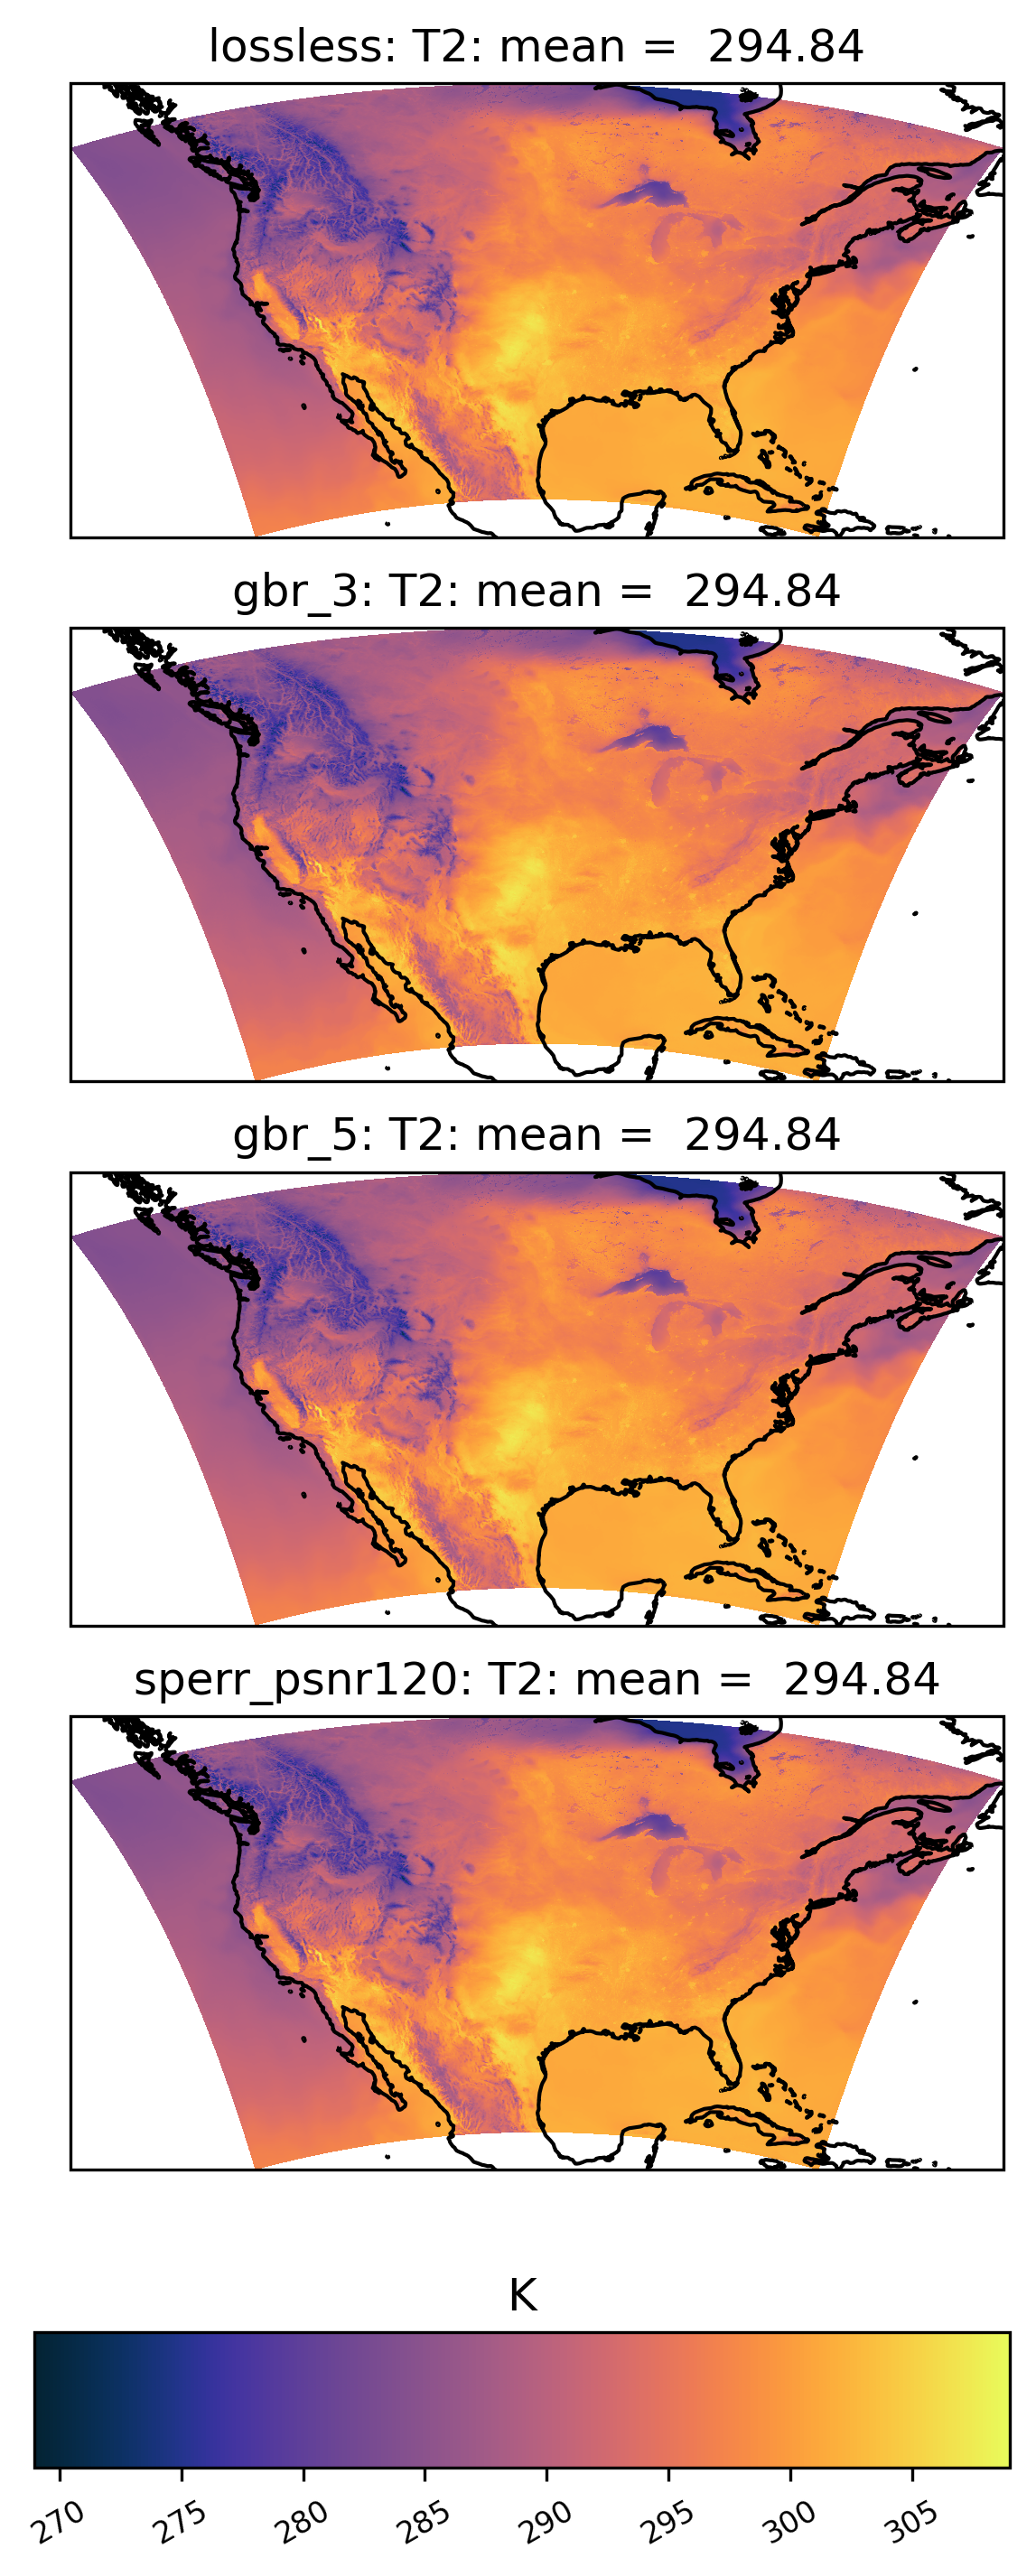

In [20]:
# plot mean T2 field (across 24 time slices) for several compression options
ldcpy.plot(
    T2_col,
    "T2",
    sets=["lossless", "gbr_3", "gbr_5", "sperr_psnr120"],
    calc="mean",
    plot_type="spatial",
    color="cmo.thermal",
    vert_plot=True,
)

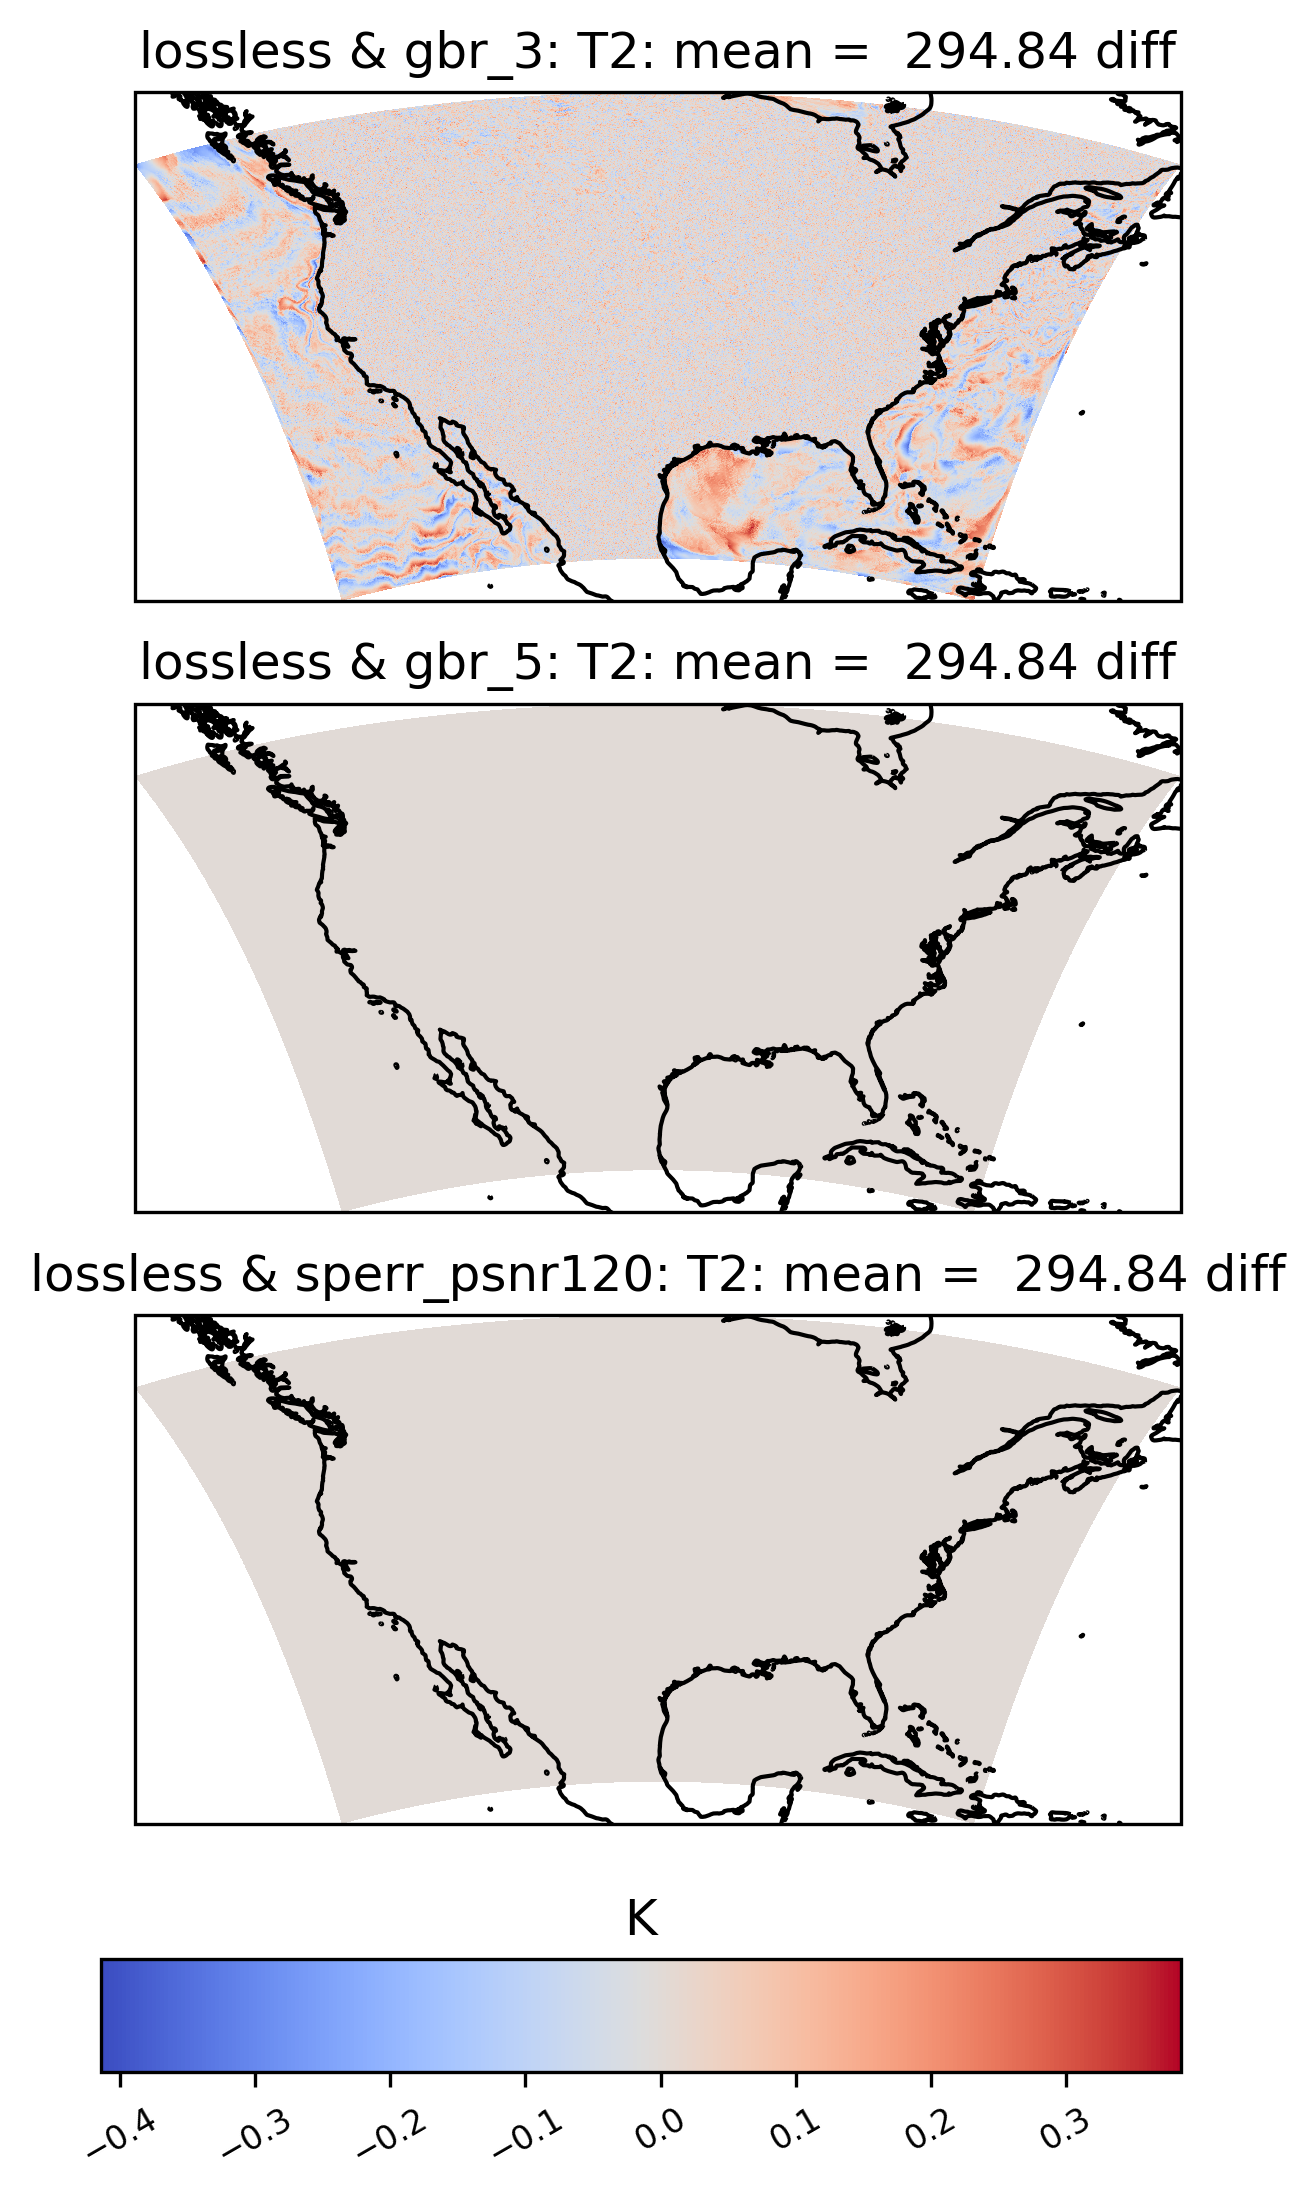

In [21]:
# plot difference in the mean T2 field - for a couple of compression options across all 24 time slices
ldcpy.plot(
    T2_col,
    "T2",
    sets=["lossless", "gbr_3", "gbr_5", "sperr_psnr120"],
    calc="mean",
    calc_type="diff",
    vert_plot=True,
)

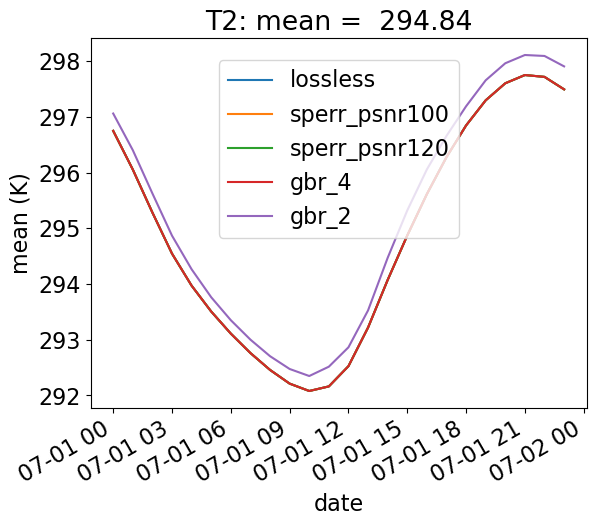

In [22]:
# Time-series plot of T2 mean
ldcpy.plot(
    T2_col,
    "T2",
    sets=[
        "lossless",
        "sperr_psnr100",
        "sperr_psnr120",
        "gbr_4",
        "gbr_2",
    ],
    calc="mean",
    plot_type="time_series",
    vert_plot=True,
    legend_loc="best",
)

In [23]:
# let's look at RAINNCV data
varname = 'RAINNCV'
filename = 'wrf2d_combined_RAINNCV.nc'
ds_all = []
ds_label = []
ds_size = []
# wrf files have to be open and post-processsed
for i in comp_opts:
    full_filename = base_dir + varname + "/" + i + "/" + filename
    # print(full_filename)
    ds_label.append(i)
    ds_all.append(xr.open_dataset(full_filename, engine="netcdf4", chunks={"time": 1}).xwrf.postprocess())
    ds_size.append(os.path.getsize(full_filename))
rainncv_ds_dict = dict(zip(ds_label, ds_all))
rainncv_size_dict = dict(zip(ds_label, ds_size))

# sorted
indx = np.argsort(ds_size)[::-1]
sorted_ds_size = [ds_size[i] for i in indx]
sorted_ds_label = [ds_label[i] for i in indx]
sorted_rainncv_size_dict = dict(zip(sorted_ds_label, sorted_ds_size))


# wrf coordinates file
ds_const = xr.open_dataset(fileconsts, engine="netcdf4").xwrf.postprocess()

# make an ldcpy collection of all of this RAINNCV data
rainncv_col = ldcpy.collect_datasets(
    "wrf",
    ["RAINNCV"],
    ds_all,
    ds_label,
    coords_ds=ds_const,
    file_sizes=ds_size,
)

dataset size in GB 2.68



In [24]:
# Notation
# sperr_psnrX = sperr with peak-signal-to-noise ratio X
# gbr_X = granular bit round with X significant digits

# compression ratio?
orig = sorted_rainncv_size_dict["lossless"]
for key in sorted_rainncv_size_dict:
    cr = round(orig / sorted_rainncv_size_dict[key], 2)
    print(key + ": ", cr)

pretreat:  0.26
sperr_psnr240:  0.59
sperr_psnr220:  0.69
sperr_psnr200:  0.82
lossless:  1.0
sperr_psnr180:  1.01
gbr_5:  1.12
gbr_4:  1.25
sperr_psnr160:  1.31
gbr_3:  1.46
sperr_psnr140:  1.83
gbr_2:  1.93
gbr_1:  2.26
sperr_psnr120:  2.83
sperr_psnr100:  5.04
sperr_psnr80:  10.93
sperr_psnr60:  29.54
sperr_psnr50:  54.09
sperr_psnr40:  111.35
sperr_psnr20:  614.81


In [25]:
# look at variable RAINNCVC statistics
# grab time slice of interest - 10?
rainncv_col_slice = rainncv_col.isel(Time=10)

# view chart of statistics
# put lossless first so the ratios of file sizes are against the lossless one
ldcpy.compare_stats(
    rainncv_col_slice,
    "RAINNCV",
    ["lossless", "gbr_1", "sperr_psnr120"],
    significant_digits=5,
    aggregate_dims=["y", "x"],
)

,lossless,gbr_1,sperr_psnr120
mean,0.00058815,0.00058858,0.00058826
variance,6.2212e-05,6.2445e-05,6.2212e-05
standard deviation,0.0078875,0.0079022,0.0078875
min value,0,0,0
min (abs) nonzero value,1.3019e-12,9.0949e-13,3.8982e-14
max value,0.99651,1,0.99651
probability positive,0.25657,0.25657,0.61259
number of zeros,1.0315e+06,1.0315e+06,5.3753e+05
99% real information cutoff bit,31,11,31
entropy estimate,0.16069,0.046097,0.35954


,gbr_1,sperr_psnr120
max abs diff,0.031229,4.3366e-06
min abs diff,0,0
mean abs diff,4.4158e-05,2.8539e-07
mean squared diff,1.815e-13,1.1462e-14
root mean squared diff,0.00057943,5.531e-07
normalized root mean squared diff,0.00058146,5.5503e-07
normalized max pointwise error,0.031339,4.3518e-06
pearson correlation coefficient,0.99731,1
ks p-value,2.8719e-43,0
spatial relative error(% > 0.0001),25.629,23.736


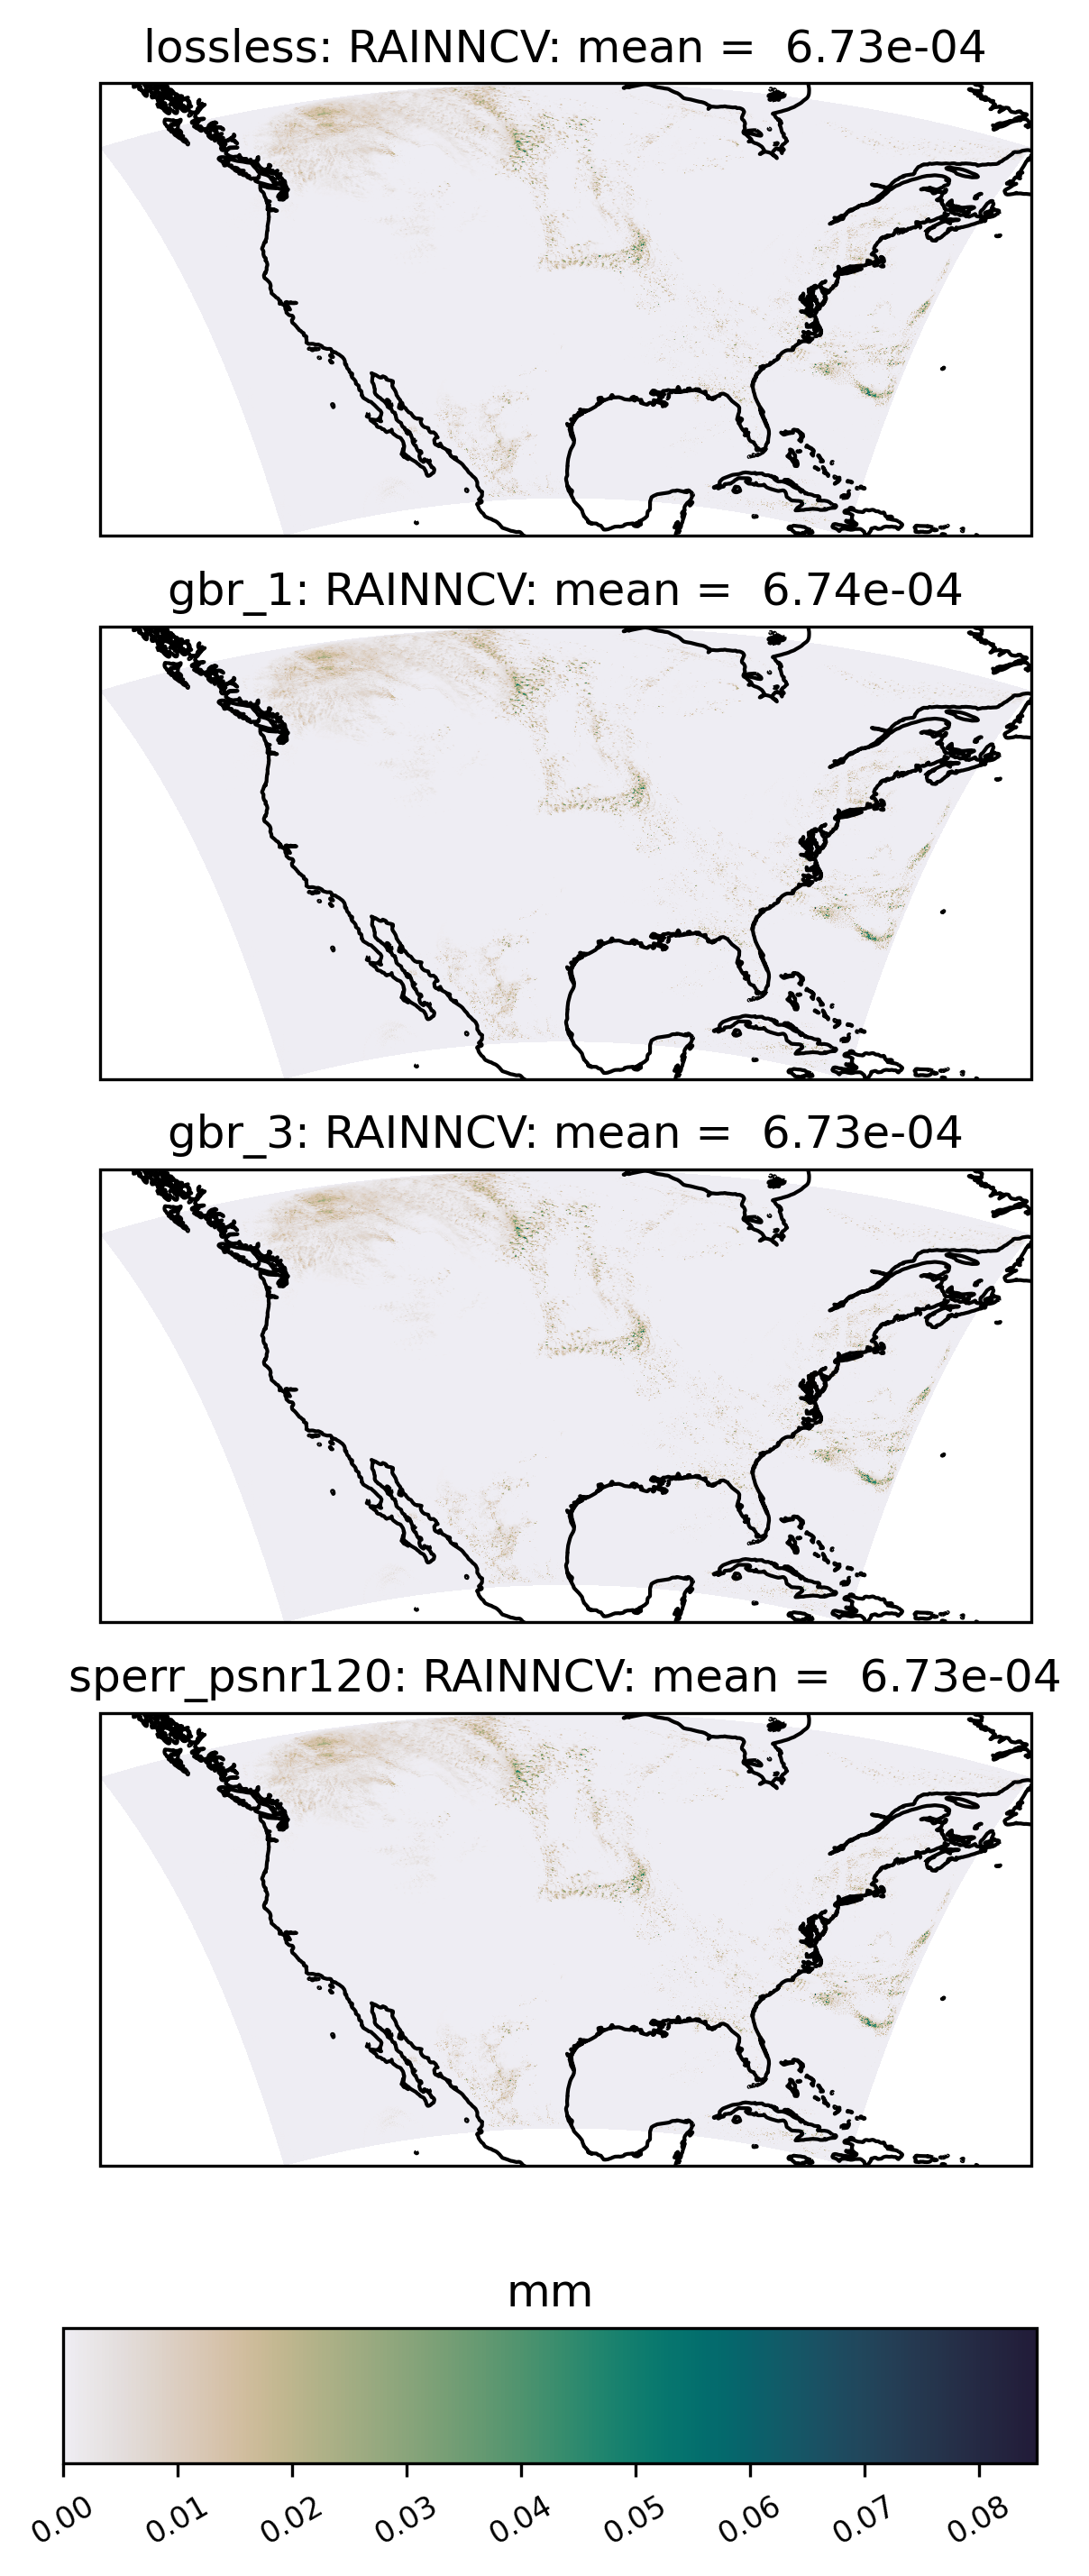

In [27]:
# Look at some plots
# plot mean RAINNCV field (across 24 time slices) for several compression options
ldcpy.plot(
    rainncv_col,
    "RAINNCV",
    sets=["lossless", "gbr_1", "gbr_3", "sperr_psnr120"],
    calc="mean",
    plot_type="spatial",
    color="cmo.rain",
    vert_plot=True,
)